In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [2]:
# Load dataset
df = pd.read_csv("online_shoppers_intention.csv")


In [3]:
df.shape

(12330, 18)

In [4]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [5]:
X = df[[
    "Administrative",
    "Administrative_Duration",
    "Informational",
    "Informational_Duration",
    "ProductRelated",
    "ProductRelated_Duration",
    "BounceRates",
    "ExitRates",
    "PageValues"
]]

In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

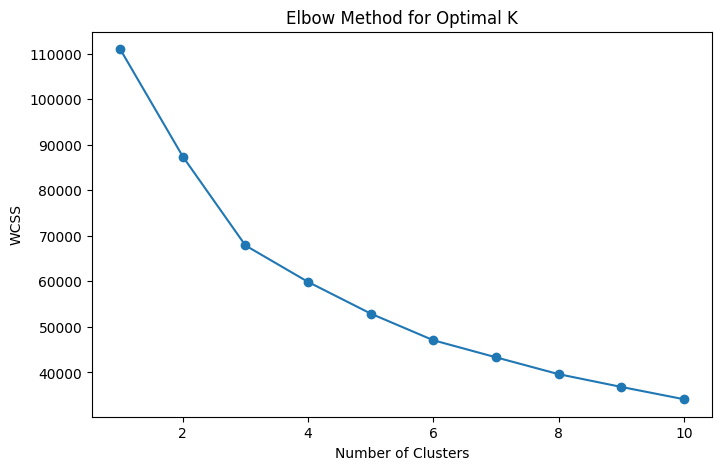

In [8]:
plt.figure(figsize=(8,5))
plt.plot(range(1, 11), wcss, marker='o')
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()

In [9]:
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4732
K = 3, Silhouette Score = 0.4943
K = 4, Silhouette Score = 0.4072
K = 5, Silhouette Score = 0.4214
K = 6, Silhouette Score = 0.4190
K = 7, Silhouette Score = 0.3798
K = 8, Silhouette Score = 0.3618
K = 9, Silhouette Score = 0.3555
K = 10, Silhouette Score = 0.2898


In [10]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

df['Cluster'] = clusters
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue,Cluster
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False,2
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False,0
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False,2
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False,0
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False,0


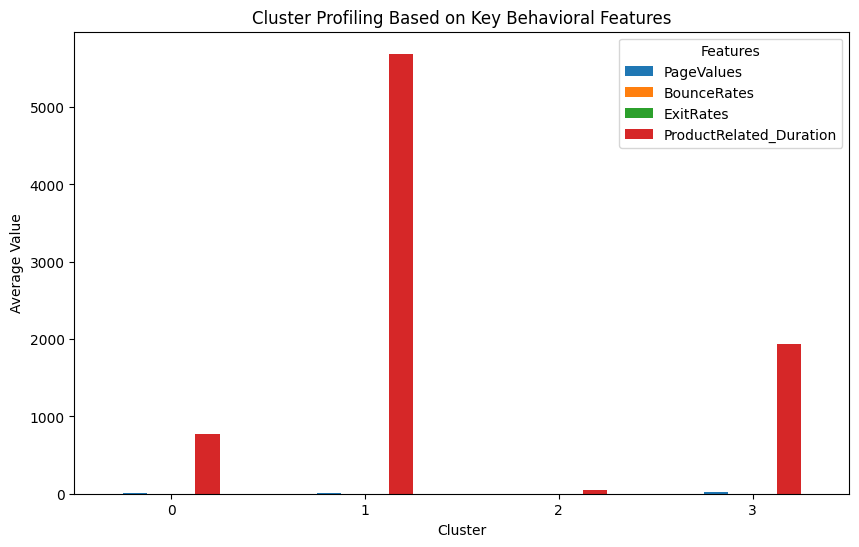

In [11]:
features = [
    "PageValues",
    "BounceRates",
    "ExitRates",
    "ProductRelated_Duration"
]

cluster_means = df.groupby("Cluster")[features].mean()

cluster_means.plot(kind="bar", figsize=(10,6))
plt.title("Cluster Profiling Based on Key Behavioral Features")
plt.ylabel("Average Value")
plt.xticks(rotation=0)
plt.legend(title="Features")
plt.show()

In [12]:
from scipy import stats

In [13]:
numerical_vars = X.columns
for col in numerical_vars:
    groups = [df[df["Cluster"] == c][col] for c in df["Cluster"].unique()]
    
    f_stat, p_value = stats.f_oneway(*groups)
    
    print(f"{col}")
    print(f"F-statistic: {f_stat:.4f}, p-value: {p_value:.6f}")
    print("-"*50)

Administrative
F-statistic: 4771.0288, p-value: 0.000000
--------------------------------------------------
Administrative_Duration
F-statistic: 1765.7791, p-value: 0.000000
--------------------------------------------------
Informational
F-statistic: 3275.0389, p-value: 0.000000
--------------------------------------------------


Informational_Duration
F-statistic: 3160.1308, p-value: 0.000000
--------------------------------------------------
ProductRelated
F-statistic: 2624.0947, p-value: 0.000000
--------------------------------------------------
ProductRelated_Duration
F-statistic: 2321.9180, p-value: 0.000000
--------------------------------------------------
BounceRates
F-statistic: 24882.4385, p-value: 0.000000
--------------------------------------------------
ExitRates
F-statistic: 11576.3162, p-value: 0.000000
--------------------------------------------------
PageValues
F-statistic: 362.7685, p-value: 0.000000
--------------------------------------------------


In [14]:
def eta_squared(groups):
    all_data = np.concatenate(groups)
    grand_mean = np.mean(all_data)
    
    ss_between = sum(len(g) * (np.mean(g) - grand_mean)**2 for g in groups)
    ss_total = sum((all_data - grand_mean)**2)
    
    return ss_between / ss_total


for col in numerical_vars:
    groups = [df[df["Cluster"] == c][col].values for c in df["Cluster"].unique()]
    
    eta = eta_squared(groups)
    
    print(f"{col}: η² = {eta:.4f}")

Administrative: η² = 0.5373
Administrative_Duration: η² = 0.3006
Informational: η² = 0.4435
Informational_Duration: η² = 0.4348
ProductRelated: η² = 0.3898
ProductRelated_Duration: η² = 0.3611
BounceRates: η² = 0.8583
ExitRates: η² = 0.7381
PageValues: η² = 0.0811


In [15]:
from scipy.stats import chi2_contingency

In [16]:
categorical_vars = [
    "Revenue",
    "Weekend",
    "VisitorType",
    "Month",
    "Region",
    "TrafficType"
]

for col in categorical_vars:
    contingency_table = pd.crosstab(df["Cluster"], df[col])
    
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    
    print(f"{col}")
    print(f"Chi2: {chi2:.4f}, p-value: {p:.6f}")
    print("-"*50)

Revenue
Chi2: 707.1524, p-value: 0.000000
--------------------------------------------------
Weekend
Chi2: 31.6619, p-value: 0.000001
--------------------------------------------------
VisitorType
Chi2: 182.2579, p-value: 0.000000
--------------------------------------------------
Month
Chi2: 425.5057, p-value: 0.000000
--------------------------------------------------
Region
Chi2: 32.2990, p-value: 0.119750
--------------------------------------------------
TrafficType
Chi2: 768.8297, p-value: 0.000000
--------------------------------------------------


In [17]:
pca = PCA(n_components=2)
components = pca.fit_transform(X_scaled)

df['PCA1'] = components[:, 0]
df['PCA2'] = components[:, 1]

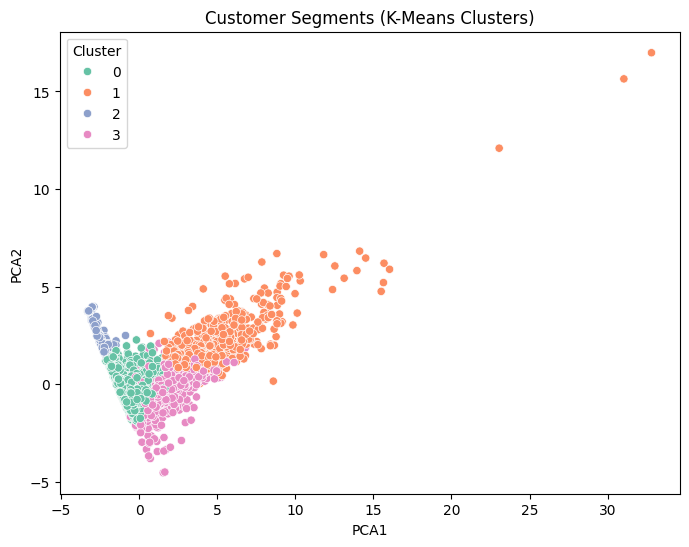

In [18]:
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='PCA1', y='PCA2',
    hue='Cluster',
    data=df,
    palette='Set2'
)

plt.title("Customer Segments (K-Means Clusters)")
plt.show()

In [19]:
df['Cluster'].value_counts()

Cluster
0    8259
3    2546
2     924
1     601
Name: count, dtype: int64